In [1]:
# 04 Clustering and Delivery Zones

#This notebook groups Points of Interest (POIs) into delivery zones
#based on spatial proximity, preparing for efficient last-mile routing.

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [3]:
# Load filtered POIs from previous steps

pois = gpd.read_file ("../routing/data/pois_largest_component.geojson")
print ("Number of POIs:", len(pois))
pois.head()

Number of POIs: 140


,fclass,nearest_node,snap_distance,geometry
0,market_place,"(376842.915, 720919.121)",70.660796,POINT (376779.993 720951.273)
1,market_place,"(377726.413, 720729.665)",19.546977,POINT (377732.671 720748.183)
2,park,"(378082.368, 719409.216)",19.953265,POINT (378102.319 719409.507)
3,arts_centre,"(377866.976, 719466.665)",44.752749,POINT (377880.409 719423.976)
4,pitch,"(377946.581, 719658.794)",42.588509,POINT (377906.133 719672.125)


In [4]:
# Extract Coordinates for Clustering

#Extract coordinates (projected CRS)

pois["x"] = pois.geometry.x
pois["y"] = pois.geometry.y

X = pois[["x", "y"]].values

In [5]:
N_ZONES = 4

In [6]:
#Apply KMeans Clustering

kmeans = KMeans (n_clusters=N_ZONES, random_state=42)
pois["zone"] = kmeans.fit_predict(X)

pois [["fclass", "zone"]].head()

,fclass,zone
0,market_place,0
1,market_place,0
2,park,0
3,arts_centre,0
4,pitch,0


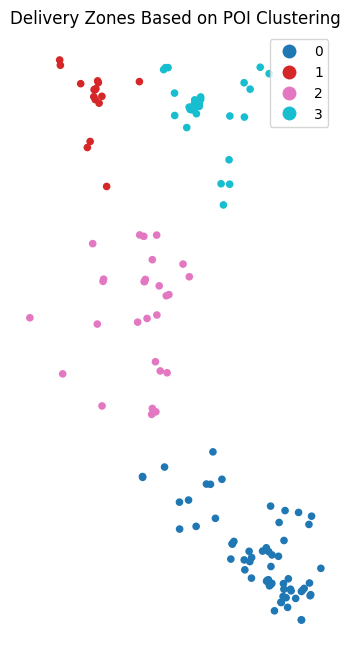

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

pois.plot (
    column = "zone",
    categorical = True,
    legend = True,
    ax=ax,
    markersize=20
)

ax.set_title("Delivery Zones Based on POI Clustering")
ax.axis ("off")
plt.show()

In [8]:
zone_counts = pois ["zone"].value_counts().sort_index()
print (zone_counts)

zone
0    65
1    16
2    28
3    31
Name: count, dtype: int64


In [9]:
# Find centroids (potential micro-hubs)

zone_centroids = pois.dissolve (by="zone").centroid
print (zone_centroids)

zone
0    POINT (378376.841 719467.652)
1    POINT (375600.454 727050.088)
2      POINT (376342.5 723517.867)
3    POINT (377456.419 726885.535)
dtype: geometry


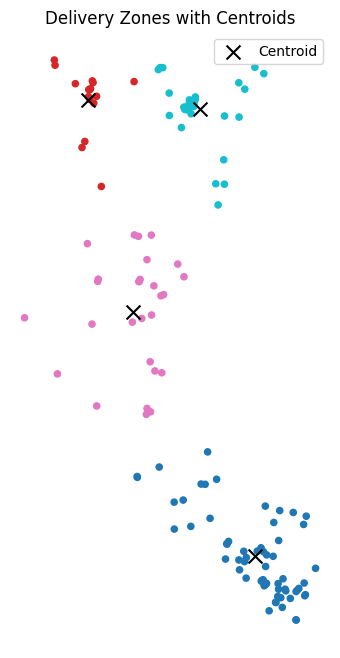

In [10]:
fig, ax = plt.subplots(figsize=(8,8))

pois.plot (column="zone", categorical=True, legend=True, ax=ax, markersize=20)
zone_centroids.plot (ax=ax, color='black', marker ='x', markersize=100, label='Centroid')

ax.set_title ("Delivery Zones with Centroids")
ax.axis("off")
plt.legend()
plt.show()

In [11]:
# Generate routes per zone

import networkx as nx 
from shapely.geometry import Point

In [12]:
import pickle

# Load the road network graph

with open ("../routing/data/road_graph.pkl", "rb") as f:
    G = pickle.load(f)

print ("Graph loaded:", len(G.nodes), "nodes", len(G.edges), "edges")

Graph loaded: 15248 nodes 16310 edges


In [38]:
import osmnx as ox

# Convert graph nodes to GeoDataFrame
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G, nodes=True, edges=True)

print(nodes_gdf.head())
print(nodes_gdf.crs)

KeyError: 'x'

In [ ]:
# Map Centroids to nearest graph nodes



import pyproj
from shapely.ops import transform

# Function to find nearest graph node

def get_nearest_node(graph, point):
    node = ox.distance.nearest_nodes(
        graph,
        X=[point.x],
        Y=[point.y]
    )
    return node[0]



In [36]:
G.graph["crs"] = pois.crs

In [34]:
print(pois.crs)


EPSG:3857


In [37]:
# Assign starting node for each zone

# Assign starting node for each zone

zone_start_nodes = {}

for zone in pois['zone'].unique():
    centroid_point = (
        pois[pois['zone'] == zone]
        .geometry
        .union_all()
        .centroid
    )
    start_node = get_nearest_node(G, centroid_point)
    zone_start_nodes[zone] = start_node

print(zone_start_nodes)




TypeError: Must pass list-like as `names`.

In [ ]:
print(pois.crs)


EPSG:3857
